# Mall Customer EDA

## Goal
Segment mall customers into natural groups using K-Means clustering —
no labels, pure unsupervised discovery. We explore two approaches:
1. Classic 2-feature clustering (Income vs Spending)
2. Multi-feature clustering (Age + Income + Spending) visualized via PCA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('Mall_Customers.csv')
data = data.set_index('CustomerID')
data.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40


In [2]:
data.isnull().sum()

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [3]:
data.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


Text(0, 0.5, 'Spending Score (1-100)')

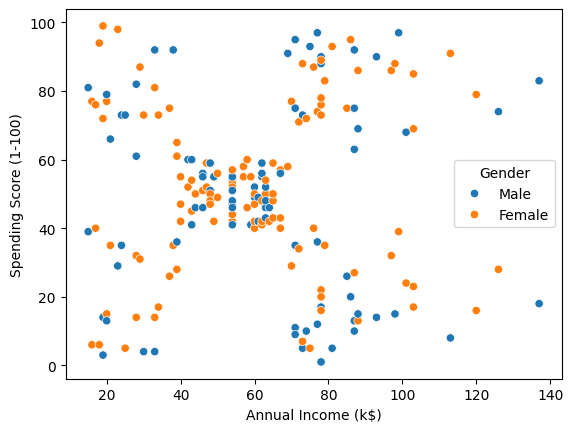

In [4]:
sns.scatterplot(data = data, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

Text(0, 0.5, 'Spending Score (1-100)')

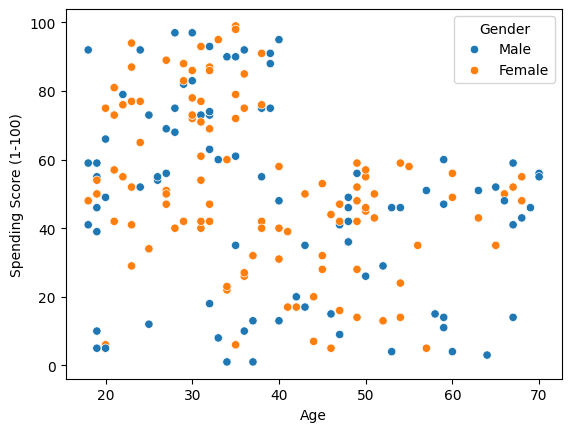

In [24]:
sns.scatterplot(data = data, x='Age', y='Spending Score (1-100)', hue='Gender')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')

## Approach 1: Income vs Spending (2 features)
We scale both features, use the elbow method to find K,
then cluster. StandardScaler ensures income (0-140) doesn't
dominate spending (1-100) in the distance calculation.

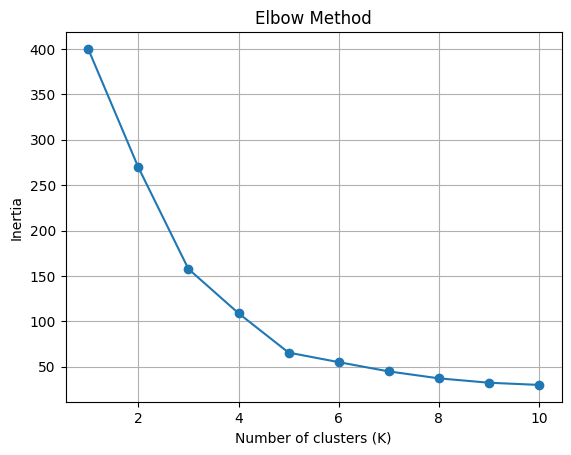

In [6]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    
plt.plot(range(1,11), inertias, 'o-')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)

In [7]:
kmeans = KMeans(n_clusters=5,random_state=42,n_init=10)
clusters = kmeans.fit_predict(X_scaled)

data['Cluster'] = clusters

print(data['Cluster'].value_counts())
data.head()

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
CustomerID,,,,,
1,Male,19,15,39,4
2,Male,21,15,81,2
3,Female,20,16,6,4
4,Female,23,16,77,2
5,Female,31,17,40,4


The 5 clusters clearly separate into distinct income-spending profiles —
matching the visual groups we expected.

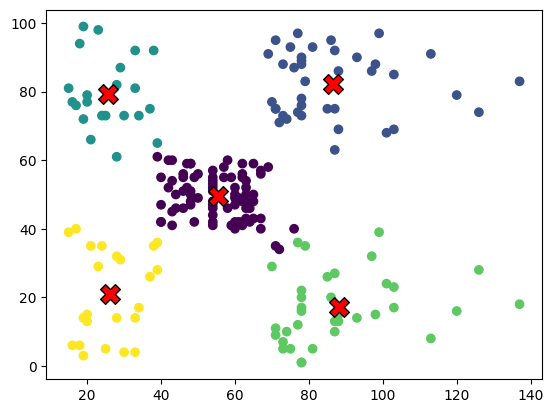

In [8]:
scatter = plt.scatter(data['Annual Income (k$)'], 
                      data['Spending Score (1-100)'],
                      c=data['Cluster'], 
                      )

centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], 
           c='red', marker='X', s=200, 
           edgecolors='black', label='Centroids')

### Business Interpretation
- **Target**: high income + high spending → most valuable, focus marketing here
- **Careful**: high income + low spending → untapped potential
- **Careless**: low income + high spending → impulse buyers, respond to sales
- **Standard / Sensible**: average and budget-conscious groups

In [9]:
cluster_summary = data.groupby('Cluster')[['Annual Income (k$)', 
                                          'Spending Score (1-100)',
                                          'Age']].mean().round(1)
print(cluster_summary)

         Annual Income (k$)  Spending Score (1-100)   Age
Cluster                                                  
0                      55.3                    49.5  42.7
1                      86.5                    82.1  32.7
2                      25.7                    79.4  25.3
3                      88.2                    17.1  41.1
4                      26.3                    20.9  45.2


In [10]:
cluster_names = {
    0: "Standard — average income, average spending",
    1: "Careful — high income, low spending (save money)",
    2: "Target — high income, high spending (best customers!)",
    3: "Careless — low income, high spending (impulse buyers)",
    4: "Sensible — low income, low spending (budget conscious)"
}

## Approach 2: Multi-feature Clustering + PCA Visualization
We add Age and cluster on 3 features. Since 3D is hard to plot,
we use PCA to project the clusters into 2D for visualization —
while keeping the original features for interpretation.

Note: Gender was dropped because PCA assumes continuous variables;
binary categories distort the variance-based projection.

In [18]:
df = pd.read_csv('Mall_Customers.csv')
df = df.set_index('CustomerID')
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40


In [19]:
# df['Gender'] = df['Gender'].str.strip().str.title()
# df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df = df.drop(columns=['Gender'])
X_scaled = StandardScaler().fit_transform(df)
pd.DataFrame(X_scaled, columns=df.columns)

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980
...,...,...,...
195,-0.276302,2.268791,1.118061
196,0.441365,2.497807,-0.861839
197,-0.491602,2.497807,0.923953
198,-0.491602,2.917671,-1.250054


Text(0, 0.5, 'Inertias')

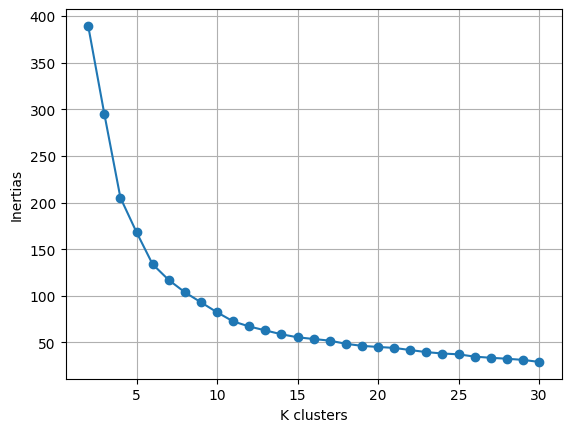

In [20]:
from sklearn.metrics import silhouette_score
inertias = []
sil = []
for k in range(2,31):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil.append(silhouette_score(X_scaled, kmeans.labels_))
    
plt.plot(range(2,31), inertias, 'o-')
plt.grid(True)
plt.xlabel('K clusters')
plt.ylabel('Inertias')

4


Text(0, 0.5, 'Silhouette Score')

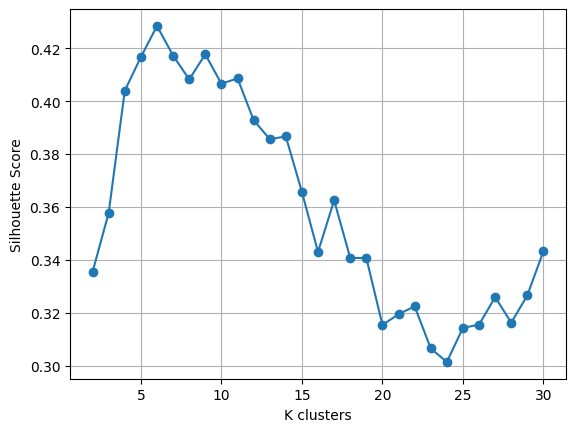

In [21]:
my = np.array(sil)
print(np.argmax(my))
plt.plot(range(2,31), sil, 'o-')
plt.grid(True)
plt.xlabel('K clusters')
plt.ylabel('Silhouette Score')

Silhouette score suggests a different optimal K than the elbow method.
For business interpretability we choose K=6 — enough granularity
without fragmenting 200 customers into tiny meaningless groups.

[0.44266167 0.33308378]


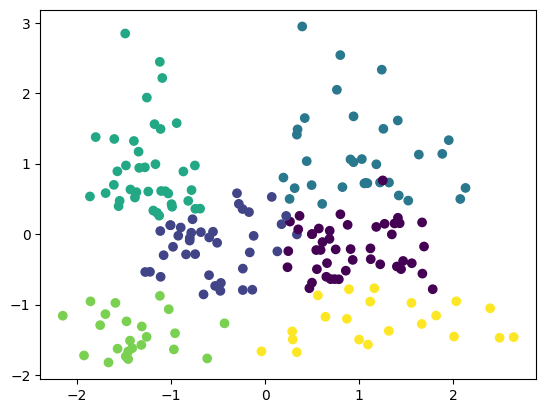

In [22]:
from sklearn.decomposition import PCA
kmeans = KMeans(n_clusters=6, n_init=10, random_state=42)

clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters

p = PCA(n_components=2)
X_pca = p.fit_transform(X_scaled)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c= clusters)

print(p.explained_variance_ratio_)

In [23]:
df.groupby('Cluster')[['Age','Annual Income (k$)','Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,56.333333,54.266667,49.066667
1,26.794872,57.102564,48.128205
2,41.939394,88.939394,16.969697
3,32.692308,86.538462,82.128205
4,25.000000,25.260870,77.608696
5,45.523810,26.285714,19.380952
